In [1]:
from contextlib import contextmanager
import time

@contextmanager
def timer(name):
    t0 = time.time()
    yield
    print(f"[{name}] done in {(time.time() - t0) * 1000:.1f} msec")

In [2]:
from collections import deque
import bisect
from pathlib import Path
import numpy as np
import z3
from itertools import product

In [3]:
def calc_mu_sigma(k, e, vs):
    mu = (k-vs)*e + vs*(1-e)
    sigma = k*e*(1-e)
    return mu, sigma

def is_out_of_range(y, x, N):
    return not ((0 <= x < N) and (0 <= y < N))

def get_div_arr(n):
    d =  (n-1) // 4 + 1
    r = 4 * d - n
    ret = [4] * (d-r)
    ret += [3] * r
    sum_ret = [0]
    for i in range(len(ret)):
        sum_ret.append(sum_ret[i] + ret[i])
    return sum_ret

def print_grid_from_coordinates(coordinates):
    x_list = []
    y_list = []
    for coordinate in coordinates:
        y, x = coordinate
        x_list.append(x)
        y_list.append(y)
    x_max = max(x_list)
    y_max = max(y_list)
    disp_grid = [["." for _ in range(x_max+1)] for _ in range(y_max+1)]
    for coordinate in coordinates:
        ty, tx = coordinate
        disp_grid[ty][tx] = "#"
    for line in disp_grid:
        print("".join(line))

def print_grid_from_map(g):
    for l in g:
        print(" ".join(map(str, l)))

In [4]:
class Env:

    def __init__(self, file_path):
        with open(file_path, mode="r") as f:
            lines = f.readlines()
            N, M, ESP = lines[0].split()
            N, M, ESP = int(N), int(M), float(ESP)
            GRID = []
            lines = lines[1:]
            for _line in lines[:M]:
                _line = _line.split()
                ps = []
                for i in range(int(_line[0])):
                    ps.append((int(_line[2 * i + 1]), int(_line[2 * i + 2])))
                GRID.append(ps)
            lines = lines[2*M:]
            ANS_GRID = []
            for _line in lines[:N]:
                ANS_GRID.append(list(map(int, _line.split())))
        
        self.N = N
        self.M = M
        self.esp = ESP
        self.grids = GRID
        self.ans_grid = ANS_GRID

        self.total_size = sum(len(g) for g in self.grids)
        self._score = 0
        self.score = 10 ** 9

        cnt = 0
        for x in range(N):
            for y in range(N):
                if self.ans_grid[y][x] > 0:
                    cnt += 1
        self.ans_point_size = cnt
    
    def query1(self, coordinate):
        y, x = coordinate
        self._score += 1
        return self.ans_grid[y][x]

    def query2(self, coordinates):
        k = len(coordinates)
        vs = sum(self.ans_grid[y][x] for y, x in coordinates)
        mu, sigma = calc_mu_sigma(k, self.esp, vs)
        rng = np.random.default_rng()
        r = rng.normal(mu, sigma)
        self._score += 1 / np.sqrt(k)
        return max(0, round(r))

    def answer(self, coordinates):
        is_ok = self.total_size == sum(self.ans_grid[y][x] for y, x in coordinates)
        if is_ok:
            self.score = self._score
        else:
            self._score += 1
        return is_ok

In [5]:
class BFSSolver:
    """
        幅優先探索で貪欲的に確定する
        RESULT: 127.69
    """

    def __init__(self, N, total_oil_num):
        self.N = N
        self.grid_count = [[-1 for _ in range(N)] for _ in range(N)]
        self.grid_response = [[False for _ in range(N)] for _ in range(N)]
        self.grid_distance = [[0 for _ in range(N)] for _ in range(N)]
        for x in range(N):
            for y in range(N):
                self.grid_distance[y][x] = min(x + 1, y + 1, N - x, N - y)

        self.total_count = 0
        self.total_oil_nums = total_oil_num

        self.next_grids = set()

    def is_ok(self):
        return self.total_count == self.total_oil_nums

    def get_plus_grids(self):
        ret = []
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_count[y][x] == -1:
                    continue
                if self.grid_count[y][x] > 0:
                    ret.append((y, x))
        return ret

    def response(self, y, x, val):
        self.grid_count[y][x] = val
        self.grid_response[y][x] = True
        if val > 0:
            self.total_count += val
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = y + dy, x + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if not self.grid_response[ny][nx]:
                    self.next_grids.add((ny, nx))
        self._update_distance(y, x)

    def get_next_search_point(self):
        if self.next_grids:
            return self.next_grids.pop()
        else:
            return self._get_far_point_from_wall()

    def _update_distance(self, y, x):
        searched = [[False for _ in range(self.N)] for _ in range(self.N)]
        self.grid_distance[y][x] = 0
        start = [(y, x)]
        search_q = deque(start)
        while search_q:
            py, px = search_q.popleft()
            searched[py][px] = True
            if searched[py][px]:
                continue
            for dy, dx in [[0, 1], [1, 0], [0, -1], [-1, 0]]:
                ny, nx = py + dy, px + dx
                if not (0 <= nx < self.N and 0 <= ny < self.N):
                    continue
                if self.grid_distance[ny][nx] == 0 or searched[ny][nx]:
                    continue
                search_q.append((ny, nx))
                self.grid_distance[ny][nx] = min(
                    self.grid_distance[ny][nx], self.grid_distance[py][px] + 1
                )

    def _get_far_point_from_wall(self):
        max_val = max(max(l for l in self.grid_distance))
        for x in range(self.N):
            for y in range(self.N):
                if self.grid_response[y][x]:
                    continue
                if self.grid_distance[y][x] == max_val:
                    return y, x

In [6]:
import threading

import ctypes
import time

# カスタムスレッドクラス
class twe(threading.Thread):
    def __init__(self, group=None, target=None, name=None, args=(), kwargs={}):
        threading.Thread.__init__(self, group=group, target=target, name=name)
        self.args = args
        self.kwargs = kwargs
        return
    
    def run(self):
        self._target(*self.args, **self.kwargs)

    def get_id(self):
        if hasattr(self, '_thread_id'):
            return self._thread_id
        for id, thread in threading._active.items():
            if thread is self:
                return id
    
    # 強制終了させる関数
    def raise_exception(self):
        thread_id = self.get_id()
        resu = ctypes.pythonapi.PyThreadState_SetAsyncExc(ctypes.c_long(thread_id), ctypes.py_object(SystemExit))
        if resu > 1:
            ctypes.pythonapi.PyThreadState_SetAsyncExc(ctypes.c_long(thread_id), 0)
            print('Failure in raising exception')

In [7]:
class SMTSolver():

    def __init__(self, env:Env):
        placements_grid_set = {}
        for m in range(env.M):
            now_grid_set = [[set() for _ in range(env.N)] for _ in range(env.N)]
            target_grids = env.grids[m]
            for x in range(env.N):
                for y in range(env.N):
                    tmp_grids = []
                    is_ok = True
                    for coordinate in target_grids:
                        ny, nx = coordinate[0] + y, coordinate[1] + x
                        if is_out_of_range(ny, nx, env.N):
                            is_ok = False
                            break
                        tmp_grids.append((ny, nx))
                    if not is_ok:
                        continue
                    for coordinate in tmp_grids:
                        ty, tx = coordinate
                        now_grid_set[ty][tx].add((y, x))
            placements_grid_set[m] = now_grid_set
        
        self.placements_grid_set = placements_grid_set

        var_x = {}
        total_grid = {}

        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            var_x[m, y, x] = z3.Bool(f"var_x{m, y, x}")
        for y, x in product(list(range(env.N)), list(range(env.N))):
            total_grid[y, x] = z3.Int(f"total_grid{y, x}")
        
        self.var_x = var_x
        self.total_grid = total_grid

        self.env = env

    def solve(self, querys):
        z3_solver = z3.Solver()
        env = self.env

        # 配列外参照になる場合はダメ
        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            target_grids = env.grids[m]
            for coordinate in target_grids:
                ny, nx = coordinate[0] + y, coordinate[1] + x
                if is_out_of_range(ny, nx, env.N):
                    z3_solver.add(self.var_x[m,y,x]==False)

        # 配置はどれか1つを選択しなければならない
        for m in range(env.M):
            now_vars = []
            for y, x in product(list(range(env.N)), list(range(env.N))):
                ind = y*env.N + x
                self.var_x[m, y, x] = z3.Bool(f"var_x{m, y, x}")
                now_vars.append(self.var_x[m, y, x])
            z3_solver.add(z3.Sum(now_vars) == 1)

        # 配置した箇所に対応するグリッドが加算される
        for y, x in product(list(range(env.N)), list(range(env.N))):
            bool_vars = []
            for m in range(env.M):
                for ty, tx in self.placements_grid_set[m][y][x]:
                    bool_vars.append(self.var_x[m ,ty, tx])
            z3_solver.add(self.total_grid[y, x] == z3.Sum(bool_vars))
        
        # 制約を満たす
        for query in querys:
            coordinate, resp = query
            y, x = coordinate
            z3_solver.add(self.total_grid[y, x] == resp)
        
        # 解を求める
        z3_solver.set('timeout', 350)
        with timer("solve"):
            if not z3_solver.check() == z3.sat:
                return None
            model = z3_solver.model()

        placement_ans = []
        for m, y, x in product(list(range(env.M)), list(range(env.N)), list(range(env.N))):
            if model.eval(self.var_x[m, y, x]):
                placement_ans.append((m, y, x))

        point_ans = set()
        for m, y, x in placement_ans:
            target_grids = env.grids[m]
            for coordinate in target_grids:
                ny, nx = coordinate[0] + y, coordinate[1] + x
                point_ans.add((ny, nx))
        

        return point_ans

In [8]:
def judge_run_smt(env):
    return True
    th = [(10, 6), (11, 5), (12, 4), (13, 4), (14, 3), (15, 2)]
    return any(env.N <= n and env.M <= m for n, m in th)

In [9]:
smt_solved_result = []

def solve(env: Env):
    TIME_OUT = 15

    smt_level = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.75, 1.0]
    start_time = time.time()
    bsf_solver = BFSSolver(env.N, total_oil_num=env.total_size)
    querys = []
    for i in range(1, 1000):

        # --- BFS Solver --- #
        y, x = bsf_solver.get_next_search_point()
        resp = env.query1((y, x))
        bsf_solver.response(y, x, resp)
        querys.append(((y, x), resp))
        if bsf_solver.is_ok():
            env.answer(bsf_solver.get_plus_grids())
            # print("GRID OK")
            break

        # --- SMT Solver --- #
        if not judge_run_smt(env):
            continue
        if time.time() - start_time > TIME_OUT:
            # 実行時間3秒以内に収めるため
            continue
        if i >= env.N**2 * smt_level[0]:
            smt_solver = SMTSolver(env)
            point_ans = smt_solver.solve(querys)
            if point_ans is None:
                continue
            if env.answer(point_ans):
                smt_solved_result.append((env.N, env.M, smt_level[0], env.score, env.ans_point_size))
                print("SOLVER OK!!!!")
                break
            smt_level.pop(0)

In [10]:
import random

scores = []
n_size = []
ans_points = []

def main():
    random.seed(0)
    for test_num in range(1000):
        env = Env(file_path = Path(f"./in/{test_num:0>4}.txt"))
        n_size.append(env.N**2)
        ans_points.append(env.ans_point_size)
        solve(env)
        scores.append(env.score)
main()

[solve] done in 357.0 msec
[solve] done in 351.5 msec
[solve] done in 356.0 msec
[solve] done in 327.1 msec
[solve] done in 355.7 msec
[solve] done in 356.4 msec
[solve] done in 355.7 msec
[solve] done in 357.0 msec
[solve] done in 357.0 msec
[solve] done in 355.7 msec
[solve] done in 356.2 msec
[solve] done in 355.9 msec
[solve] done in 356.9 msec
[solve] done in 357.0 msec
[solve] done in 356.6 msec
[solve] done in 357.0 msec
[solve] done in 355.3 msec
[solve] done in 355.0 msec
[solve] done in 361.0 msec
[solve] done in 358.6 msec
[solve] done in 356.9 msec
[solve] done in 356.9 msec
[solve] done in 356.0 msec
[solve] done in 356.2 msec
[solve] done in 356.2 msec
[solve] done in 356.1 msec
[solve] done in 357.2 msec
[solve] done in 355.0 msec
[solve] done in 356.1 msec
[solve] done in 356.7 msec
[solve] done in 358.0 msec
[solve] done in 357.9 msec
[solve] done in 98.1 msec
SOLVER OK!!!!
[solve] done in 104.3 msec
[solve] done in 126.2 msec
[solve] done in 134.1 msec
[solve] done in

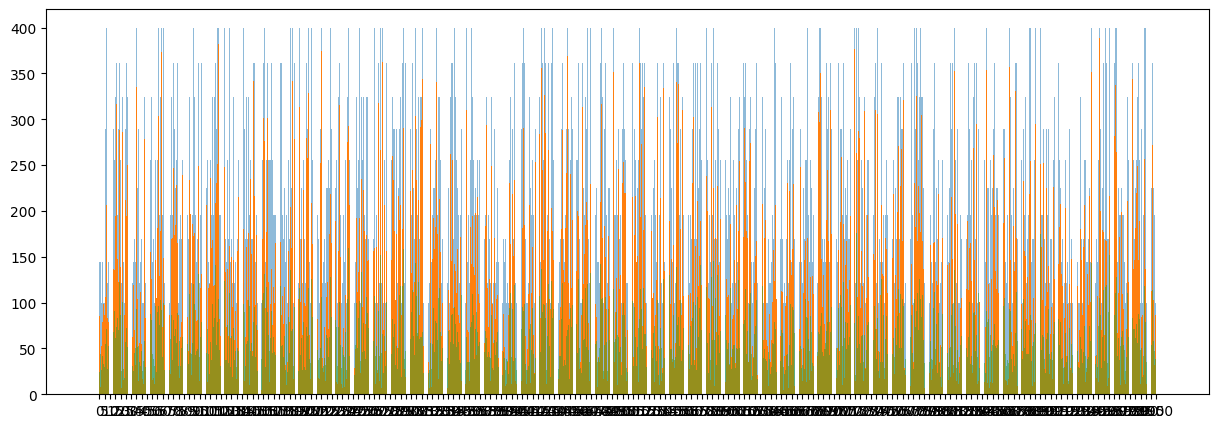

134.13


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.bar(list(range(len(n_size))), n_size, alpha=0.5)
plt.bar(list(range(len(scores))), scores)
plt.bar(list(range(len(ans_points))), ans_points, alpha=0.5)

plt.xticks(range(0, len(scores)+1, 5))
plt.show()

print(sum(scores) / len(scores))

In [29]:
m_list = []
n_list = []
level_list = []
point_list = []
for result in smt_solved_result:
    n, m, level, score, point_size = result
    n_list.append(n)
    m_list.append(m)
    level_list.append(level)
    point_list.append(point_size)

In [35]:
c.keys(), c.values()

(dict_keys([0.05, 0.45, 0.75, 0.6, 0.1, 0.2, 0.4, 0.25, 0.15, 0.3, 0.35, 0.5]),
 dict_values([63, 11, 15, 13, 65, 18, 10, 18, 30, 20, 9, 8]))

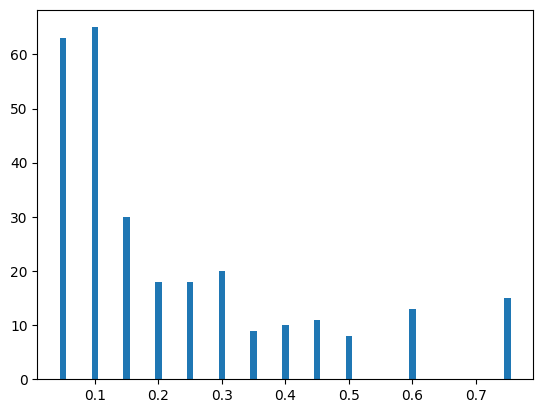

In [37]:
from collections import Counter
c = Counter(level_list)
plt.bar(c.keys(), c.values(), width=0.01)
plt.show()

In [ ]:
# 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.75, 1.0

[0.075, 0.125, 0.2, 0.3, 0.55, 1]

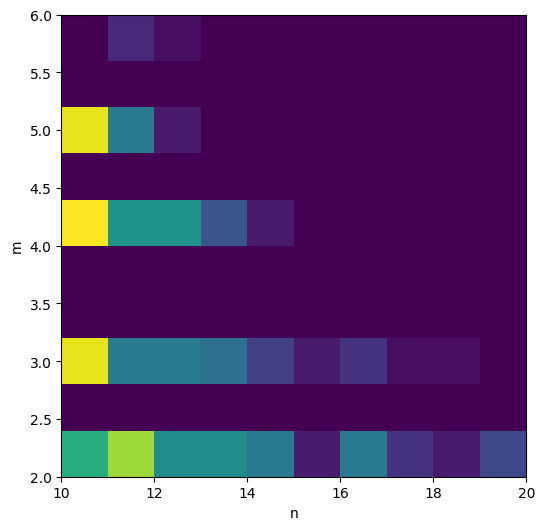

In [26]:
plt.figure(figsize=(6,6))
# plt.scatter(n_list, m_list, s=3)
plt.hist2d(n_list, m_list)
plt.xlabel("n")
plt.ylabel("m")
plt.show()

In [ ]:
# 10, 5
# 11, 5
# 12, 4
# 13, 3
# 14, 2
# 15, 2

In [12]:
smt_solved_result

[(12, 3, 0.05, 8, 44),
 (10, 5, 0.45, 53, 27),
 (10, 5, 0.75, 86, 30),
 (11, 5, 0.6, 83, 28),
 (14, 2, 0.05, 10, 30),
 (11, 2, 0.05, 7, 25),
 (12, 2, 0.1, 16, 28),
 (10, 3, 0.75, 86, 18),
 (12, 2, 0.75, 119, 25),
 (12, 3, 0.2, 32, 50),
 (17, 2, 0.05, 15, 53),
 (11, 2, 0.4, 56, 35),
 (13, 4, 0.25, 55, 47),
 (10, 2, 0.15, 17, 25),
 (10, 2, 0.1, 11, 36),
 (11, 5, 0.6, 83, 30),
 (10, 3, 0.3, 35, 19),
 (12, 2, 0.1, 16, 44),
 (13, 3, 0.1, 18, 39),
 (10, 3, 0.1, 11, 31),
 (12, 3, 0.15, 24, 48),
 (12, 2, 0.3, 49, 33),
 (10, 2, 0.75, 86, 26),
 (14, 2, 0.1, 22, 60),
 (10, 5, 0.75, 86, 31),
 (13, 4, 0.1, 18, 58),
 (10, 3, 0.15, 17, 24),
 (13, 4, 0.25, 47, 33),
 (11, 4, 0.15, 21, 44),
 (11, 2, 0.1, 14, 41),
 (11, 4, 0.1, 14, 28),
 (12, 3, 0.35, 57, 36),
 (16, 3, 0.05, 13, 71),
 (14, 2, 0.3, 64, 31),
 (12, 4, 0.45, 73, 37),
 (10, 3, 0.15, 17, 30),
 (10, 4, 0.35, 41, 32),
 (17, 2, 0.05, 15, 90),
 (14, 2, 0.05, 10, 96),
 (13, 4, 0.25, 47, 42),
 (10, 4, 0.6, 70, 25),
 (10, 2, 0.1, 11, 26),
 (10, 2, 0.

In [13]:
# BFS RESULT 1000 > 145.714